# Confidence Regions Tutorial

This tutorial demonstrates **surface confidence regions** (CoPE sets) for the
true mean of brain-imaging data: given noisy per-subject surface maps, we build
an *inner* set (locations confidently above a threshold `c`) and an *outer* set
(locations that may be above `c`), controlling the false-discovery rate.

We work on the HCP S1200 inflated cortical surface, using the empirical
working-memory mean/std maps shipped with `statbrainz` to give the simulated
data a realistic spatial profile.

> **Note on scope.** A *Simultaneous Confidence Regions* (`scopes`) section is
> omitted: `scopes` depends on `fastperm`/`fastperm_mean`, which are not part of
> the StatBrainz source and so cannot be run.

## Setup

All data used here is bundled inside the `statbrainz` package, so the tutorial
is self-contained.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import statbrainz as sb


## Load the surface

`loadsrf('hcp')` returns the bundled HCP 32k inflated surface as a bilateral
dict with `lh`/`rh` fields.

In [2]:
hcp_srf = sb.loadsrf("hcp")
print("hemispheres:", list(hcp_srf))
print("left:  %d vertices, %d faces" % (hcp_srf["lh"]["nvertices"], hcp_srf["lh"]["nfaces"]))
print("right: %d vertices, %d faces" % (hcp_srf["rh"]["nvertices"], hcp_srf["rh"]["nfaces"]))


hemispheres: ['lh', 'rh']
left:  32492 vertices, 64980 faces
right: 32492 vertices, 64980 faces


Load the empirical HCP working-memory mean and std maps, which are
bundled alongside the surface.

In [3]:
hcp_wm_path = os.path.join(sb.data_dir(), "Surface", "hcp", "hcpWM_surface.npz")
with np.load(hcp_wm_path) as z:
    hcp_data_mean = {"lh": z["mean_lh"], "rh": z["mean_rh"]}
    hcp_data_std = {"lh": z["std_lh"], "rh": z["std_rh"]}
print("mean maps:", {h: hcp_data_mean[h].shape for h in hcp_data_mean})


mean maps: {'lh': (32492,), 'rh': (32492,)}


## Generate data

Make `nsubj` smoothed-noise surface maps, then rescale each hemisphere to the
empirical HCP mean and std so the simulated signal has a realistic spatial
profile. `xbar` is the per-vertex sample mean; `mask` flags the (non-NaN)
cortical region of interest.

In [4]:
FWHM, nsubj = 10, 50
rng = np.random.default_rng(0)  # fixed seed for reproducibility

data = sb.srf_noise(hcp_srf, FWHM, nsubj, rng=rng)

xbar, mask = {}, {}
for h in ("lh", "rh"):
    x = data[h]
    x = x / np.std(x)                  # unit-variance noise
    x = x * hcp_data_std[h][:, None]   # impose empirical std
    x = x + hcp_data_mean[h][:, None]  # impose empirical mean
    data[h] = x
    with np.errstate(invalid="ignore"):
        # medial-wall vertices are all-NaN; the resulting NaN mean is expected.
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            xbar[h] = np.nanmean(x, axis=1)
    mask[h] = ~np.isnan(xbar[h])

print("data shapes:", {h: data[h].shape for h in data})
print("mask sizes: ", {h: int(mask[h].sum()) for h in mask})


data shapes: {'lh': (32492, 50), 'rh': (32492, 50)}
mask sizes:  {'lh': 29696, 'rh': 29716}


## FDR CoPE sets

`srf_fdr_crs(data, mask, c)` returns the lower (inner) and upper (outer)
confidence sets for the excursion set `{mean > c}` at FDR level 0.05, restricted
to the mask. Here `c = 0`.

In [5]:
c = 0
lower_band_im, upper_band_im = sb.srf_fdr_crs(data, mask, c)

for h in ("lh", "rh"):
    print(f"{h}: inner (lower) set = {int(np.sum(lower_band_im[h])):5d} vertices, "
          f"outer (upper) set = {int(np.sum(upper_band_im[h])):5d} vertices")


lh: inner (lower) set = 18845 vertices, outer (upper) set =  6737 vertices
rh: inner (lower) set = 16574 vertices, outer (upper) set =  6728 vertices


### Visualise the CoPE sets

`srf_color_crs` turns the bands + sample mean into an RGB colour map using the
"bowring" scheme (blue = inner/confident set, red = outer set), and `srfplot`
renders it on the surface. We mask `xbar` to the cortical ROI first, then show a
2x2 grid: left/right hemispheres, lateral (side) and medial (backside) views.

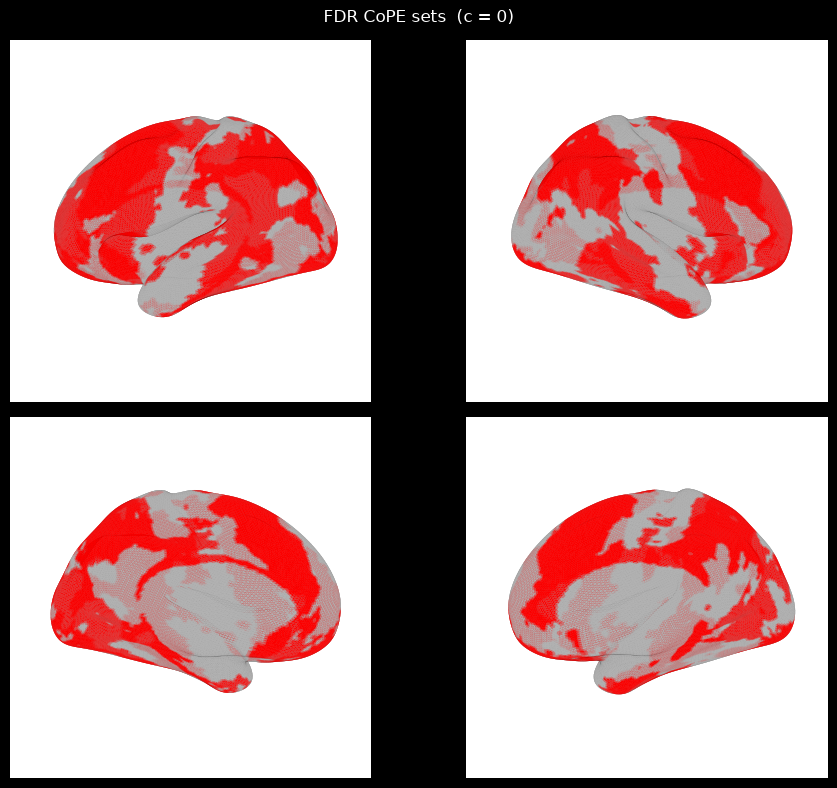

In [6]:
xbar_masked = {h: xbar[h] * mask[h] for h in ("lh", "rh")}

fig = plt.figure(figsize=(10, 8), facecolor="black")
panel = 1
for doback in (0, 1):                       # lateral, then medial
    for h in ("lh", "rh"):
        color_map = sb.srf_color_crs(
            hcp_srf[h], lower_band_im[h], upper_band_im[h],
            xbar_masked[h], c, 1, "bowring", 0,
        )
        ax = fig.add_subplot(2, 2, panel, projection="3d")
        sb.srfplot(hcp_srf[h], color_map, view_vec=doback, ax=ax)
        panel += 1
fig.suptitle("FDR CoPE sets  (c = 0)", color="white")
plt.tight_layout()
plt.show()


## FDR CoPE sets, computed step by step

The previous section wrapped the whole pipeline in `srf_fdr_crs`. Here we
reproduce it from the primitives for a non-zero threshold `c = 1`:

1. one-sample t-statistic per vertex of `data - c` (`mvtstat`),
2. convert to one-sided p-values (`tstat2pval`),
3. find the FDR threshold `maxp` over both hemispheres jointly (`fdrBH`),
4. the **upper** set is `{p < maxp}`; the **lower** set uses the same procedure
   on `1 - p`.

In [7]:
c = 1
tstats, xbar2 = {}, {}
for h in ("lh", "rh"):
    tstats[h], xbar2[h], _, _ = sb.mvtstat(data[h] - c)

# p-values over both hemispheres jointly (one-sided, df = nsubj - 1).
pvals_all = sb.tstat2pval(
    sb.nan2zero(np.concatenate([tstats["rh"], tstats["lh"]])), nsubj - 1, False
)
pvals = {h: sb.tstat2pval(tstats[h], nsubj - 1, False) for h in ("lh", "rh")}

# Upper set: reject small p-values.
_, _, _, maxp = sb.fdrBH(pvals_all)
upper_set = {h: pvals[h] < maxp for h in ("lh", "rh")}

# Lower set: reject small (1 - p) values.
_, _, _, maxp2 = sb.fdrBH(1 - pvals_all)
lower_set = {h: (1 - pvals[h]) > maxp2 for h in ("lh", "rh")}

for h in ("lh", "rh"):
    print(f"{h}: upper set = {int(upper_set[h].sum()):5d}, "
          f"lower set = {int(lower_set[h].sum()):5d}")


lh: upper set =  2366, lower set =  8008
rh: upper set =  2319, lower set =  7505


Render these sets directly with `srf_colour`: blue for the lower
(inner) set, red for the upper (outer) set.

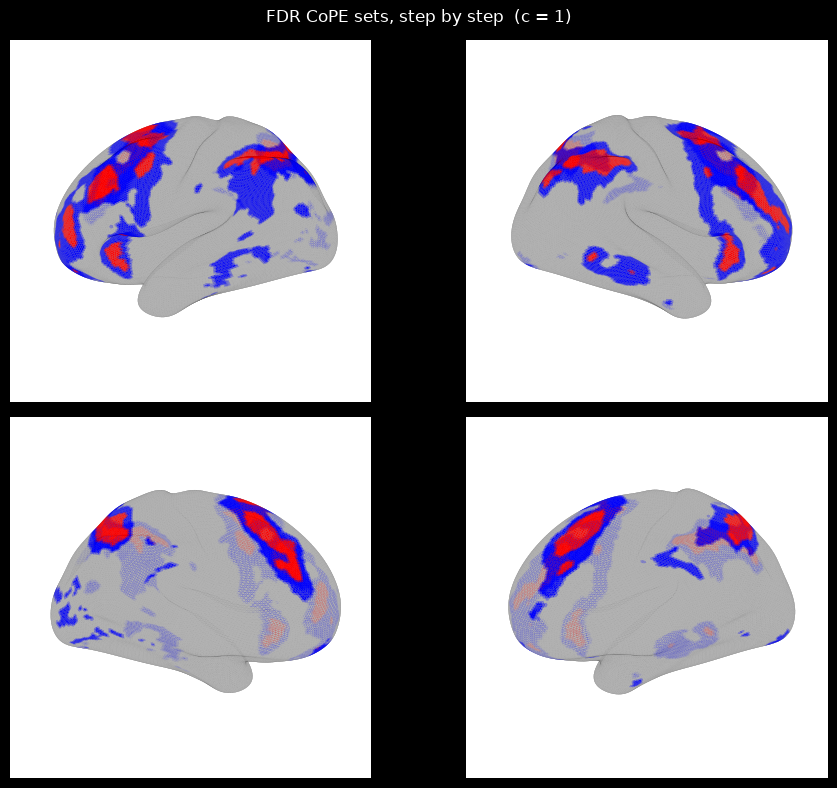

In [8]:
fig = plt.figure(figsize=(10, 8), facecolor="black")
panel = 1
for doback in (0, 1):
    for h in ("lh", "rh"):
        color_map = sb.srf_colour(
            hcp_srf[h],
            [lower_set[h], upper_set[h]],
            [[0, 0, 1], [1, 0, 0]],
        )
        ax = fig.add_subplot(2, 2, panel, projection="3d")
        sb.srfplot(hcp_srf[h], color_map, view_vec=doback, ax=ax)
        panel += 1
fig.suptitle("FDR CoPE sets, step by step  (c = 1)", color="white")
plt.tight_layout()
plt.show()


## Summary

- **`srf_fdr_crs`** gives FDR-controlled inner/outer confidence sets for a
  surface excursion set in one call.
- The same result can be assembled from **`mvtstat`**, **`tstat2pval`** and
  **`fdrBH`**.
- **`srf_color_crs`** / **`srf_colour`** + **`srfplot`** render the sets on the
  cortical surface.

The *Simultaneous Confidence Regions* (`scopes`) section is omitted because its
`fastperm` dependency is not part of the StatBrainz source.